In [36]:
from typing import TypedDict, Annotated
from langgraph.graph import add_messages, StateGraph, START, END
from langchain_groq import ChatGroq
from langchain_core.messages import AIMessage, HumanMessage
from dotenv import load_dotenv
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.prebuilt import ToolNode

### Child State

In [37]:
load_dotenv()

class ChildState(TypedDict):
    messages: Annotated[list, add_messages]

search_tool = TavilySearchResults(max_results=2)
tools = [search_tool]

In [38]:
llm = ChatGroq(model="llama-3.1-8b-instant")
llm_with_tools = llm.bind_tools(tools=tools)

In [39]:
def agent(state: ChildState):
    return {
        "messages": [llm_with_tools.invoke(state["messages"])],
    }

def tools_router(state: ChildState):
    last_message = state["messages"][-1]

    if(hasattr(last_message, "tool_calls") and len(last_message.tool_calls) > 0):
        return "tool_node"
    else:
        return END

In [40]:
tool_node = ToolNode(tools=tools)
subgraph = StateGraph(ChildState)

subgraph.add_node("agent", agent)
subgraph.add_node("tool_node", tool_node)
subgraph.set_entry_point("agent")

subgraph.add_conditional_edges("agent", tools_router)
subgraph.add_edge("tool_node", "agent")

search_app = subgraph.compile()

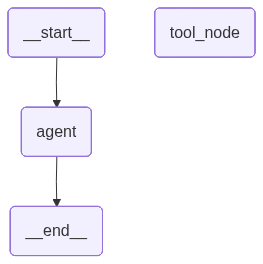

In [41]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(
    Image(
        search_app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API
        )
    )
)

In [42]:
print("=== Child Graph Result ===")
child_result = search_app.invoke({"messages": [HumanMessage(content="How is the weather in Bangladesh")]})
print(f"Messages: {len(child_result['messages'])} total")
print(f"Last message: {child_result['messages'][-1]}")


=== Child Graph Result ===
Messages: 4 total
Last message: content='The current weather in Bangladesh is expected to be dry with temporary partly cloudy sky. The night and day temperatures are likely to remain nearly unchanged. The lowest temperature was recorded at 9.2 degrees Celsius at Tetulia, while the highest temperature recorded yesterday was 31.0 degrees Celsius at Ambagan.' additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 1284, 'total_tokens': 1346, 'completion_time': 0.075521168, 'completion_tokens_details': None, 'prompt_time': 0.125330338, 'prompt_tokens_details': None, 'queue_time': 0.059911092, 'total_time': 0.200851506}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019bd551-2dba-7091-970a-6d94a26f1d61-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 1284, 'outpu

### Case-1: Shared Schema (Direct Embedding) Parent State

In [43]:
class ParentState(TypedDict):
    messages: Annotated[list, add_messages]

In [44]:
parent_graph_case1 = StateGraph(ParentState)

parent_graph_case1.add_node("search_agent", search_app)

parent_graph_case1.add_edge(START, "search_agent")
parent_graph_case1.add_edge("search_agent", END)

parent_app_case1 = parent_graph_case1.compile()

print("\n=== Case-1: Shared Schema Result ===")
result_case1 = parent_app_case1.invoke({"messages": [HumanMessage(content="What is the weather in Bangladesh?")]})
print(f"Messages: {len(result_case1['messages'])} total")
print(f"Last message: {result_case1['messages'][-1]}")



=== Case-1: Shared Schema Result ===
Messages: 4 total
Last message: content='The current weather in Bangladesh is comfortable with low temperatures ranging from 18°C to 28°C. There should be no rainy days in Bangladesh during January, but the days are very hot, so it is recommended to hang out outside during the afternoons and evening time. The average temperature in Bangladesh in January is around 28°C during the day and 18°C at night.' additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 78, 'prompt_tokens': 2404, 'total_tokens': 2482, 'completion_time': 0.180075699, 'completion_tokens_details': None, 'prompt_time': 0.216962607, 'prompt_tokens_details': None, 'queue_time': 0.058004282, 'total_time': 0.397038306}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_ff2b098aaf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019bd551-3352-7bc3-95a5-c3c80a2dd88e-0' tool_calls=[] invalid_

### Case-2: Different Schema (Invoke with Transformation)

In [45]:
class QueryState(TypedDict):
    query: str
    response: str

def search_agent_case2(state: QueryState) -> Dict:
    subgraph_input = {
        "messages": [HumanMessage(content=state["query"])]
    }
    subgraph_output = search_app.invoke(subgraph_input)
    assistant_message = subgraph_output["messages"][-1]
    return {"response": assistant_message.content}

parent_graph_case2 = StateGraph(QueryState)
parent_graph_case2.add_node("search_agent", search_agent_case2)
parent_graph_case2.add_edge(START, "search_agent")
parent_graph_case2.add_edge("search_agent", END)

parent_app_case2 = parent_graph_case2.compile()

print("\n=== Case-2: Different Schema Result ===")
output_case2 = parent_app_case2.invoke({"query": "What is the weather in Bangladesh?", "response": ""})
print(f"Query: {output_case2['query']}")
print(f"Response: {output_case2['response']}")



=== Case-2: Different Schema Result ===
Query: What is the weather in Bangladesh?
Response: The current weather in Bangladesh is mostly clear with temperatures ranging from 18°C to 28°C. It is recommended to hang out outside during the afternoons and evening time due to the hot weather. There should be no rainy days in January.
